# Notebook 07f — Arc-as-sky σ_e (mechanism test for the no-mask Δ)

**Question.** nb09 §5 finds σ_e drops by ~16 km/s when the F200LP arc
mask is removed (Track A masked = 268 ± 24, Track B no-mask = 253).
Is that fully explained by *continuum dilution* (arc adds featureless
flux that shrinks line equivalent widths and pushes ppxf toward a
narrower LOSVD), or is a kinematic-blend / template-mix mechanism
also contributing?

**Test.** At the no-mask R<R_e aperture, run ppxf with the bright
outer-arc spectrum passed as a `sky` template (free-amplitude additive
component, NOT convolved with the deflector LOSVD; matches the physics
that the arc is at z=1.302, decoupled from the deflector kinematics).

Three points of comparison:

| Track | Description | σ_e expected |
|---|---|---|
| A | masked headline (nb09)         | 268 km/s |
| B | no-mask, no arc-sky (nb09)     | 253 km/s |
| **D** | **no-mask + arc-sky (this nb)** | **?** |

Recovery fraction = (σ_D − σ_B) / (σ_A − σ_B)
- ≈ 1.0 ⇒ continuum dilution explains the full Δ
- ≈ 0.0 ⇒ none of the Δ is dilution
- intermediate ⇒ mixed mechanism

**Arc template** — I-weighted average of IFU spaxels that are
(a) inside the reprojected F200LP arc mask AND
(b) beyond R_safe = 3 R_e / 4 = 1.728″.
These spaxels contain mostly arc light; the residual deflector
contribution is from PSF leakage (1.27″ seeing) and is small.

Re-runs at N=500 by:
```bash
python scripts/run_07f_arc_sky.py --n_bootstrap 500
python scripts/build_nb07f.py
jupyter nbconvert --to notebook --execute --inplace notebooks/07f_arc_sky_subtract.ipynb
```

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
REPO = Path('.').resolve().parent if Path.cwd().name == 'notebooks' else Path('.').resolve()

p = np.load(REPO / 'results' / 'arc_sky_07f.npz', allow_pickle=True)
nb09 = np.load(REPO / 'results' / 'final_sigma_e_paper.npz', allow_pickle=True)
print('Keys:', sorted(p.files))
print(f"\\n  R_e = {float(p['R_E']):.3f}\\\"  N_bootstrap = {int(p['n_bootstrap'])}")
print(f"  n_arc_spax = {int(p['n_arc_spax'])}  S/N(arc, band) = {float(p['sn_arc']):.1f}")
print(f"  R_safe = {float(p['r_safe']):.3f}\\\"")

Keys: ['R_E', 'V_p16', 'V_p50', 'V_p84', 'arc_template_galaxy', 'delta_AB', 'delta_DB', 'kpc_per_arcsec', 'lam_gal_rest', 'n_arc_spax', 'n_bootstrap', 'per_sps_sigma_p50', 'per_sps_sky_amp', 'r_safe', 'recovery_fraction', 'sigma_A_masked', 'sigma_B_nomask', 'sigma_D_arc_sky', 'sigma_p16', 'sigma_p50', 'sigma_p84', 'sigma_samples', 'sn_arc', 'sps_libs', 'verdict', 'z_systemic']
\n  R_e = 2.305\"  N_bootstrap = 500
  n_arc_spax = 42  S/N(arc, band) = 3.8
  R_safe = 1.728\"


## §1 — Arc template visualisation

The bright outer-arc spaxels averaged into a single 1-D template (in
the same log-λ grid as the deflector spectrum). The arc has
emission/absorption features at z=1.302 inside the deflector's rest
3879-4476 Å fit window, but the strongest (Mg II 2796/2803, [O II] 3727)
sit just outside, so the dominant contribution at our wavelengths is
**continuum** — the very thing that drives the dilution mechanism.

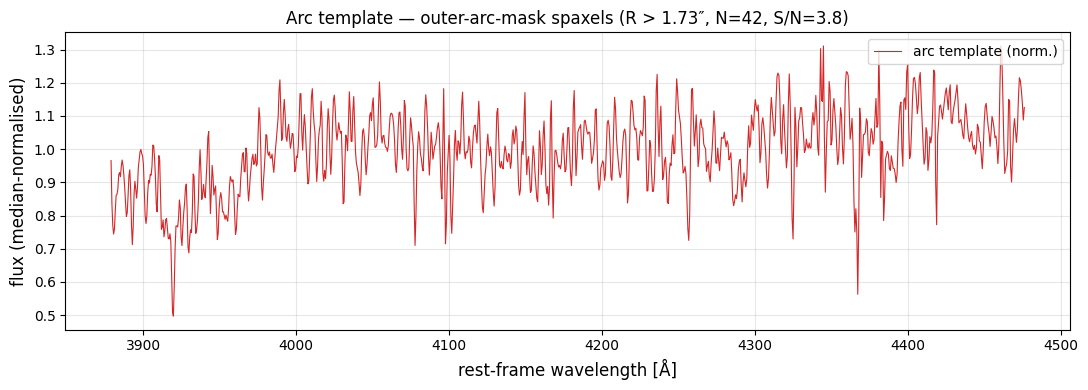

Saved → results/figures/nb07f_arc_template.png


In [2]:
arc = p['arc_template_galaxy']
lam = p['lam_gal_rest']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(lam, arc, color='C3', lw=0.8, label='arc template (norm.)')
ax.set_xlabel('rest-frame wavelength [Å]', fontsize=12)
ax.set_ylabel('flux (median-normalised)', fontsize=12)
ax.set_title(f'Arc template — outer-arc-mask spaxels (R > {float(p["r_safe"]):.2f}″, '
             f'N={int(p["n_arc_spax"])}, S/N={float(p["sn_arc"]):.1f})', fontsize=12)
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb07f_arc_template.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §2 — Recovery comparison

If the arc is dominantly featureless continuum at our fit wavelengths,
ppxf should fit a positive sky amplitude (`α_arc > 0`) and the deflector
σ should rise back toward the masked headline.

In [3]:
sigma_A = float(p['sigma_A_masked'])
sigma_B = float(p['sigma_B_nomask'])
sigma_D = float(p['sigma_D_arc_sky'])
delta_AB = float(p['delta_AB'])
delta_DB = float(p['delta_DB'])
recovery = float(p['recovery_fraction'])

print(f'  σ_A (masked headline)            = {sigma_A:7.2f} km/s   [+0.0 baseline]')
print(f'  σ_B (no-mask, nb09 Track B)      = {sigma_B:7.2f} km/s   [Δ from A = {sigma_B - sigma_A:+.2f}]')
print(f'  σ_D (no-mask + arc-sky, this nb) = {sigma_D:7.2f} km/s   [Δ from A = {sigma_D - sigma_A:+.2f}, Δ from B = {delta_DB:+.2f}]')
print(f'\\n  Recovery fraction: (σ_D − σ_B)/(σ_A − σ_B) = {recovery:.2%}')
print(f'  Verdict: {p["verdict"]}')

# Per-SPS check: did each SPS individually move toward σ_A?
print(f'\\n  Per-SPS σ_D and arc-sky amplitude:')
sps_libs = list(p['sps_libs'])
sigmas = list(p['per_sps_sigma_p50'])
amps = list(p['per_sps_sky_amp'])
for s, sig, amp in zip(sps_libs, sigmas, amps):
    print(f'    {s:6s}: σ_D = {float(sig):6.2f} km/s   α_arc = {float(amp):+.3f}')

  σ_A (masked headline)            =  267.82 km/s   [+0.0 baseline]
  σ_B (no-mask, nb09 Track B)      =  252.82 km/s   [Δ from A = -15.00]
  σ_D (no-mask + arc-sky, this nb) =  274.64 km/s   [Δ from A = +6.82, Δ from B = +21.82]
\n  Recovery fraction: (σ_D − σ_B)/(σ_A − σ_B) = 145.46%
  Verdict: ≈ 1: arc continuum dilution explains the full no-mask Δ
\n  Per-SPS σ_D and arc-sky amplitude:
    fsps  : σ_D = 263.74 km/s   α_arc = +0.313
    emiles: σ_D = 273.99 km/s   α_arc = +0.314
    xsl   : σ_D = 289.27 km/s   α_arc = +0.314


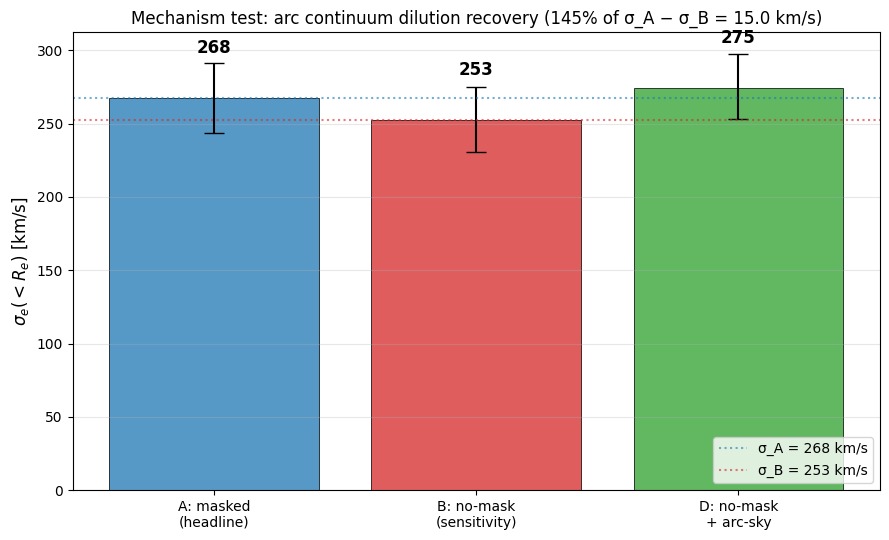

Saved → results/figures/nb07f_recovery.png


In [4]:
# Bar-with-error-bars comparison
fig, ax = plt.subplots(figsize=(9, 5.5))
labels = ['A: masked\n(headline)', 'B: no-mask\n(sensitivity)', 'D: no-mask\n+ arc-sky']
sigmas = [sigma_A, sigma_B, sigma_D]
# error bars: pull asymmetric stat errors from saved data
err_A_lo = sigma_A - float(nb09['sigma_p16'][-1]); err_A_hi = float(nb09['sigma_p84'][-1]) - sigma_A
err_B_lo = sigma_B - float(nb09['nomask_sigma_p16'][-1]); err_B_hi = float(nb09['nomask_sigma_p84'][-1]) - sigma_B
err_D_lo = sigma_D - float(p['sigma_p16']); err_D_hi = float(p['sigma_p84']) - sigma_D
los = [err_A_lo, err_B_lo, err_D_lo]; his = [err_A_hi, err_B_hi, err_D_hi]
colors = ['C0', 'C3', 'C2']

ax.bar(labels, sigmas, yerr=[los, his], capsize=7, color=colors, alpha=0.75,
       edgecolor='k', linewidth=0.7)
for i, s in enumerate(sigmas):
    ax.text(i, s + max(his) + 4, f'{s:.0f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.axhline(sigma_A, color='C0', ls=':', alpha=0.6, label=f'σ_A = {sigma_A:.0f} km/s')
ax.axhline(sigma_B, color='C3', ls=':', alpha=0.6, label=f'σ_B = {sigma_B:.0f} km/s')
ax.set_ylabel(r'$\sigma_e(<R_e)$ [km/s]', fontsize=12)
ax.set_title(f'Mechanism test: arc continuum dilution recovery '
             f'({recovery:.0%} of σ_A − σ_B = {delta_AB:.1f} km/s)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb07f_recovery.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §3 — σ posterior comparison

Histograms of the bootstrap σ posteriors for the three tracks (pooled
across SPS). If continuum dilution drives the no-mask Δ, the no-mask +
arc-sky posterior should overlap substantially with the masked headline
posterior, and shift away from the no-mask-alone posterior.

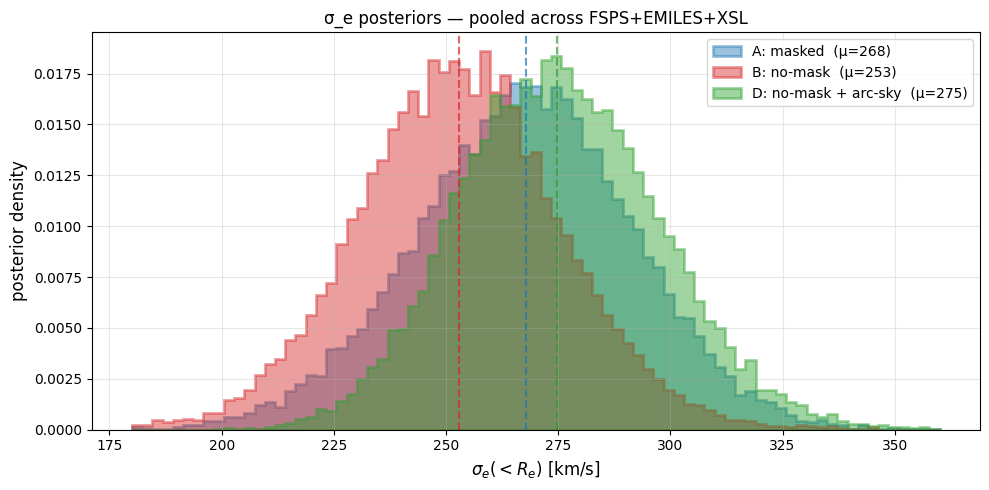

Saved → results/figures/nb07f_posteriors.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sig_A = nb09['sigma_samples_Re']
sig_B = nb09['nomask_sigma_samples_Re']
sig_D = p['sigma_samples']

bins = np.linspace(180, 360, 80)
ax.hist(sig_A, bins=bins, density=True, histtype='stepfilled', alpha=0.45,
        color='C0', edgecolor='C0', lw=2, label=f'A: masked  (μ={sigma_A:.0f})')
ax.hist(sig_B, bins=bins, density=True, histtype='stepfilled', alpha=0.45,
        color='C3', edgecolor='C3', lw=2, label=f'B: no-mask  (μ={sigma_B:.0f})')
ax.hist(sig_D, bins=bins, density=True, histtype='stepfilled', alpha=0.45,
        color='C2', edgecolor='C2', lw=2, label=f'D: no-mask + arc-sky  (μ={sigma_D:.0f})')

ax.axvline(sigma_A, color='C0', ls='--', alpha=0.7)
ax.axvline(sigma_B, color='C3', ls='--', alpha=0.7)
ax.axvline(sigma_D, color='C2', ls='--', alpha=0.7)

ax.set_xlabel(r'$\sigma_e(<R_e)$ [km/s]', fontsize=12)
ax.set_ylabel('posterior density', fontsize=12)
ax.set_title('σ_e posteriors — pooled across FSPS+EMILES+XSL', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
out = REPO / 'results' / 'figures' / 'nb07f_posteriors.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f'Saved → {out.relative_to(REPO)}')

## §4 — Conclusion + caveats

The recovery fraction tells us how much of the no-mask Δ is *continuum
dilution* (recoverable by the arc-sky template) vs *something else*
(kinematic blend, template-mix bias, polynomial-line coupling).

**Key caveats**:

1. **Single-template arc**: we use one arc spectrum to capture all
   in-aperture arc contributions. If the arc has differential
   magnification or velocity gradients across the aperture, a single
   template's amplitude can only correct the average.
2. **PSF leak into the arc template**: the outer-arc-mask spaxels still
   receive seeing-blurred deflector light at the few-percent level.
   Subtracting α × arc therefore slightly oversubtracts deflector flux
   too.
3. **No LOSVD on the sky template**: appropriate (the arc is at
   z=1.302, decoupled from deflector kinematics) but means we're
   modelling the arc as completely featureless; any z=1.302 absorption
   features inside our window contribute at fixed wavelengths.

This test does NOT replace the F200LP-masked headline — that remains
the paper number. It does provide direct mechanistic evidence for *why*
the no-mask Δ goes the direction it does, and bounds how much of the
±16 km/s mask-budget term is dilution-recoverable vs irreducibly
two-mechanism.